# Identitas Diri
- Nama: Muhammad Abiya Makruf
- Username: Abiyamf

## Import library

In [85]:
import random

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf


In [86]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

## Data loading & Eksplorasi Data

In [87]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
raw_df = pd.read_csv(csv_url)

In [88]:
raw_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [89]:
raw_df.tail()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
53145,2023-10-19 19:00:00,28750.75,2.984059e+07,53.630054,109.926882,129.065981,7.459700
53146,2023-10-19 20:00:00,28715.38,4.997623e+07,53.531282,111.721905,129.268969,7.118597
53147,2023-10-19 21:00:00,28604.09,3.205666e+07,53.221944,113.055031,129.287930,6.210037
53148,2023-10-19 22:00:00,28649.65,2.200420e+07,53.332673,114.513131,129.219782,6.515616
53149,2023-10-19 23:00:00,28713.71,1.758298e+07,53.487941,116.161806,129.096002,6.963753


In [90]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [91]:
TARGET = 'Close'
CANDIDATE_FEATURES = [column for column in raw_df.columns if column not in ['Date', TARGET]]

print('Target:', TARGET)
print('Kandidat fitur non-target:', CANDIDATE_FEATURES)


Target: Close
Kandidat fitur non-target: ['Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']


## Data preparation

In [92]:
df = raw_df.copy()

In [93]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset=['Date']).reset_index(drop=True)

In [94]:
ROLLING_WINDOW = 24

def add_rolling_features(df, target_column=TARGET, rolling_window=ROLLING_WINDOW):
    enriched = df.copy()
    enriched['close_roll_mean_24'] = enriched[target_column].rolling(rolling_window, min_periods=rolling_window).mean()
    enriched = enriched.dropna().reset_index(drop=True)
    return enriched

df = add_rolling_features(df)


Jumlah data split: 10817 833 4993
Fitur non-target dengan korelasi tertinggi pada train: ['ATR', 'RSI', 'Volume USDT']
Fitur final yang digunakan: ['Close', 'ATR', 'RSI', 'Volume USDT', 'close_roll_mean_24']


,abs_corr_to_close_train
ATR,0.811703
RSI,0.407694
Volume USDT,0.194947
KAMAO,0.134827
MACD_Hist,0.024458


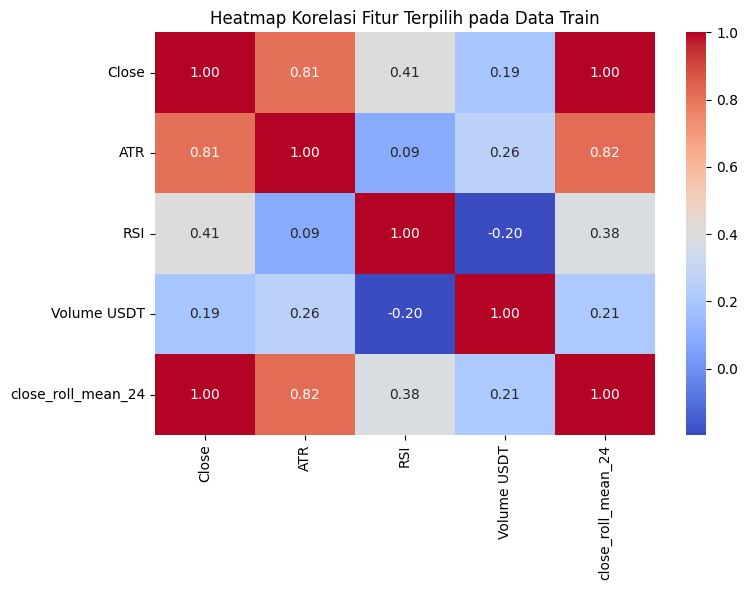

In [95]:
# Split data dilakukan sebelum pemilihan fitur final agar korelasi hanya dihitung dari data train.
TRAIN_RATIO = 0.65
VAL_RATIO = 0.05
TEST_RATIO = 0.30

train_df = df.iloc[:int(len(df) * TRAIN_RATIO)].reset_index(drop=True)
val_df = df.iloc[int(len(df) * TRAIN_RATIO):int(len(df) * (TRAIN_RATIO + VAL_RATIO))].reset_index(drop=True)
test_df = df.iloc[int(len(df) * (TRAIN_RATIO + VAL_RATIO)):].reset_index(drop=True)

train_correlation_to_target = (
    train_df[[TARGET, *CANDIDATE_FEATURES]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
TOP_CORRELATED_FEATURES = train_correlation_to_target.head(3).index.tolist()
FEATURE = [TARGET, *TOP_CORRELATED_FEATURES, 'close_roll_mean_24']

print('Jumlah data split:', len(train_df), len(val_df), len(test_df))
print('Fitur non-target dengan korelasi tertinggi pada train:', TOP_CORRELATED_FEATURES)
print('Fitur final yang digunakan:', FEATURE)
display(train_correlation_to_target.to_frame(name='abs_corr_to_close_train'))

plt.figure(figsize=(8, 6))
sns.heatmap(train_df[FEATURE].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Terpilih pada Data Train')
plt.tight_layout()
plt.show()


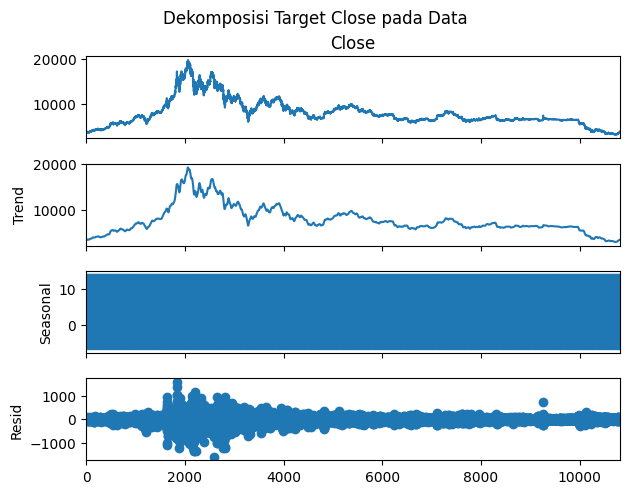

In [96]:
# Analisis dekomposisi untuk melihat komponen tren, musiman, dan residu
decomposition = seasonal_decompose(train_df[TARGET], model='additive', period=24)
decomposition.plot()
plt.suptitle('Dekomposisi Target Close pada Data', y=1.02)
plt.show()

,lag,acf,pacf,score,significant
0,24,0.979848,-0.026112,0.979848,True
1,48,0.960940,0.001717,0.960940,True
2,72,0.941357,-0.019996,0.941357,True
3,96,0.921941,-0.007929,0.921941,True
4,168,0.865091,0.018183,0.865091,True


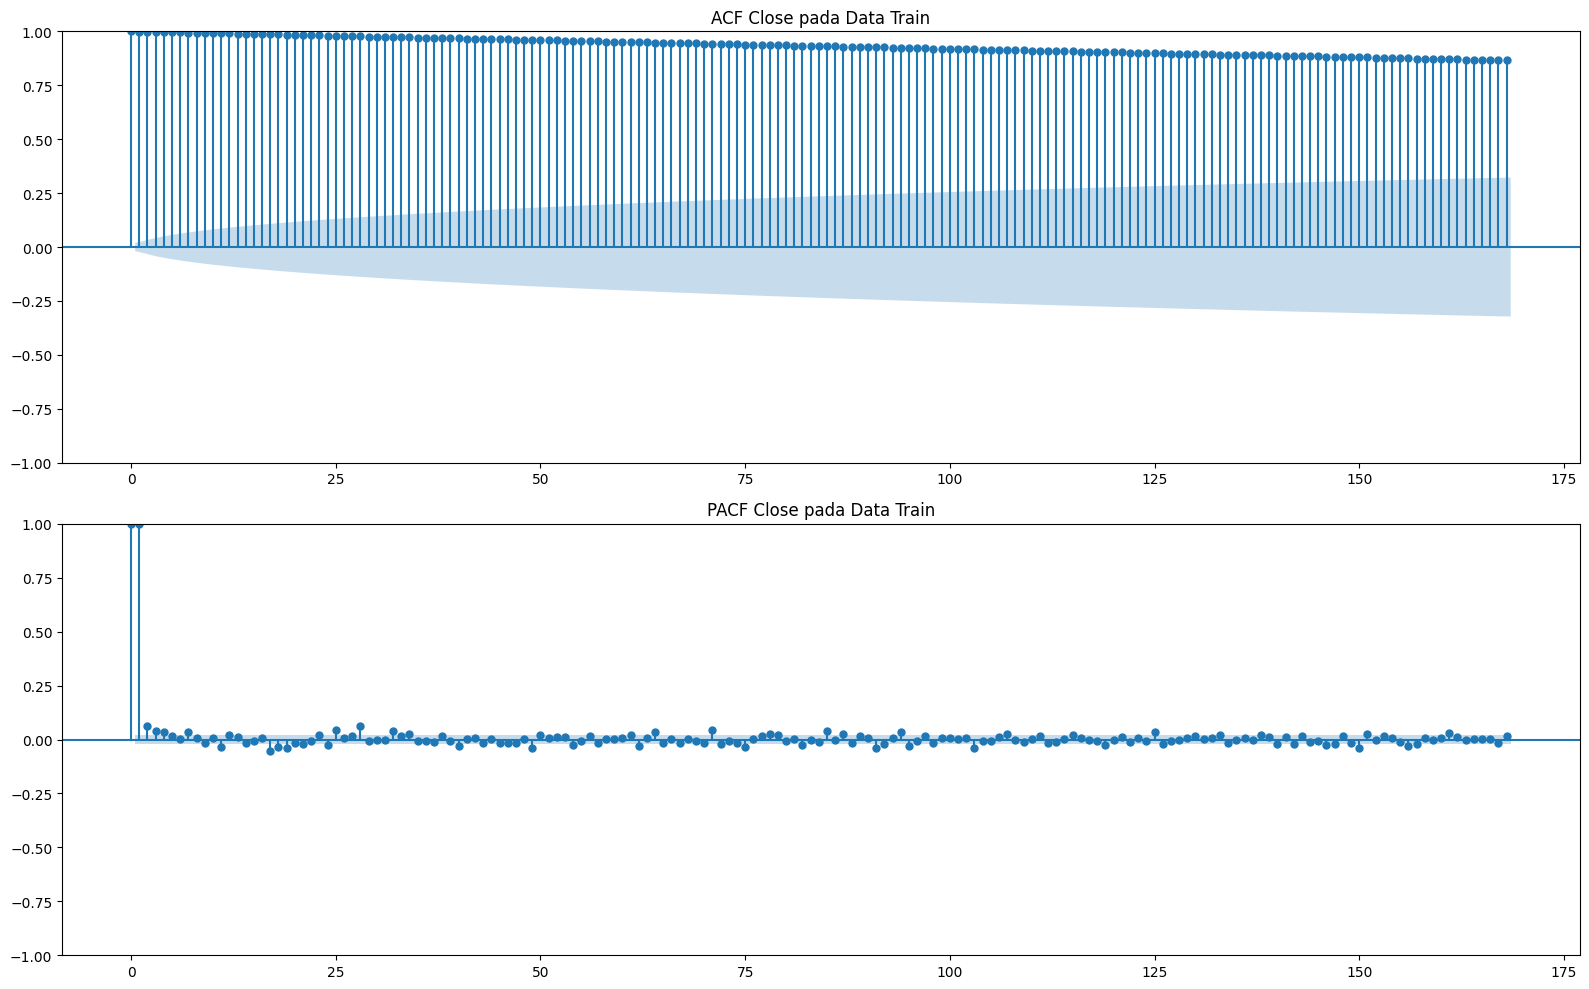

Significance threshold: 0.01885
Selected window size from ACF/PACF analysis: 48


In [97]:
WINDOW_CANDIDATES = (24, 48, 72, 96, 168)
def select_window_size_from_lag_analysis(series, candidate_windows=WINDOW_CANDIDATES):
    max_lag = max(candidate_windows)
    acf_values = acf(series, nlags=max_lag, fft=True)
    pacf_values = pacf(series, nlags=max_lag, method='ywm')
    significance_threshold = 1.96 / np.sqrt(len(series))

    lag_rows = []
    selected_window = 24
    for lag in candidate_windows:
        acf_at_lag = float(acf_values[lag])
        pacf_at_lag = float(pacf_values[lag])
        score = max(abs(acf_at_lag), abs(pacf_at_lag))
        lag_rows.append({
            'lag': lag,
            'acf': acf_at_lag,
            'pacf': pacf_at_lag,
            'score': score,
            'significant': score >= significance_threshold,
        })
        if score >= significance_threshold and selected_window == 24:
            selected_window = lag

    lag_summary = pd.DataFrame(lag_rows)
    return selected_window, significance_threshold, lag_summary
selected_window_size, significance_threshold, lag_summary_df = select_window_size_from_lag_analysis(train_df[TARGET])
display(lag_summary_df)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(train_df[TARGET], lags=max(WINDOW_CANDIDATES), ax=axes[0])
plot_pacf(train_df[TARGET], lags=max(WINDOW_CANDIDATES), ax=axes[1], method='ywm')
axes[0].set_title('ACF Close pada Data Train')
axes[1].set_title('PACF Close pada Data Train')
plt.tight_layout()
plt.show()

print(f'Significance threshold: {significance_threshold:.5f}')
print(f'Selected window size from ACF/PACF analysis: {selected_window_size}')


In [98]:
# Scale data
scalers = {}
for col in FEATURE :
    scaler = MinMaxScaler()
    scaler.fit(train_df[[col]])
    scalers[col] = scaler

for col in FEATURE :
    train_df[col] = scalers[col].transform(train_df[[col]])
    val_df[col] = scalers[col].transform(val_df[[col]])
    test_df[col] = scalers[col].transform(test_df[[col]])


In [99]:
train_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,close_roll_mean_24
0,2017-09-22 08:00:00,0.028762,0.000748,0.467362,-49.453354,0.141062,0.015093,0.031060
1,2017-09-22 09:00:00,0.026298,0.000816,0.461314,-49.745629,0.140841,-0.453320,0.030401
2,2017-09-22 10:00:00,0.024236,0.001163,0.456266,-50.150669,0.140576,-0.843745,0.029623
3,2017-09-22 11:00:00,0.022248,0.001473,0.451406,-50.661754,0.140531,-1.217532,0.028777
4,2017-09-22 12:00:00,0.025401,0.000974,0.459685,-50.963345,0.140488,-0.610674,0.028085


In [100]:
WINDOW_SIZE = selected_window_size
HORIZON = 24

def make_supervised_windows(df, feature_columns, target_column, window_size, horizon=HORIZON):
    feature_values = df[feature_columns].to_numpy(dtype=np.float32)
    target_values = df[target_column].to_numpy(dtype=np.float32)
    timestamps = df['Date'].to_numpy()
    target_index = feature_columns.index(target_column)

    X, y, y_timestamps, last_close_values = [], [], [], []
    for end_idx in range(window_size, len(df) - horizon + 1):
        start_idx = end_idx - window_size
        target_slice = slice(end_idx, end_idx + horizon)
        X.append(feature_values[start_idx:end_idx])
        y.append(target_values[target_slice].reshape(horizon, 1))
        y_timestamps.append(timestamps[target_slice])
        last_close_values.append(feature_values[end_idx - 1, target_index])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    y_timestamps = np.asarray(y_timestamps)
    last_close_values = np.asarray(last_close_values, dtype=np.float32)
    return X, y, y_timestamps, last_close_values

X_train, y_train, train_timestamps, train_last_close = make_supervised_windows(train_df, FEATURE, TARGET, WINDOW_SIZE)
X_val, y_val, val_timestamps, val_last_close = make_supervised_windows(val_df, FEATURE, TARGET, WINDOW_SIZE)
X_test, y_test, test_timestamps, test_last_close = make_supervised_windows(test_df, FEATURE, TARGET, WINDOW_SIZE)


In [101]:
def build_decoder_inputs(y_true, last_close_values):
    decoder_inputs = np.zeros_like(y_true, dtype=np.float32)
    decoder_inputs[:, 0, 0] = last_close_values
    decoder_inputs[:, 1:, 0] = y_true[:, :-1, 0]
    return decoder_inputs

train_decoder_inputs = build_decoder_inputs(y_train, train_last_close)
val_decoder_inputs = build_decoder_inputs(y_val, val_last_close)
test_decoder_inputs = build_decoder_inputs(y_test, test_last_close)

In [102]:
BATCH_SIZE = 48
EPOCHS = 8
CUSTOM_BASELINE_EPOCHS = 6
CUSTOM_SEQ2SEQ_EPOCHS = 20

def make_tf_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(X), 4096), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_tf_dataset(X_train, y_train, shuffle=True)
val_ds = make_tf_dataset(X_val, y_val, shuffle=False)
test_ds = make_tf_dataset(X_test, y_test, shuffle=False)


In [103]:
def make_seq2seq_tf_dataset(encoder_inputs, decoder_inputs, targets, batch_size=BATCH_SIZE, shuffle=False):
    inputs = {
        'encoder_inputs': encoder_inputs.astype(np.float32),
        'decoder_inputs': decoder_inputs.astype(np.float32),
    }
    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(encoder_inputs), 4096), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return dataset
train_seq2seq_ds = make_seq2seq_tf_dataset(X_train, train_decoder_inputs, y_train, shuffle=True)
val_seq2seq_ds = make_seq2seq_tf_dataset(X_val, val_decoder_inputs, y_val, shuffle=False)
test_seq2seq_ds = make_seq2seq_tf_dataset(X_test, test_decoder_inputs, y_test, shuffle=False)


## Custom layer

In [104]:
@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias

    def build(self, input_shape):
        last_dim = int(input_shape[-1])
        self.kernel = self.add_weight(
            name='kernel',
            shape=(last_dim, self.units),
            initializer='glorot_uniform',
            trainable=True,
        )
        self.bias = None
        if self.use_bias:
            self.bias = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
            )
        super().build(input_shape)

    def call(self, inputs):
        outputs = tf.linalg.matmul(inputs, self.kernel)
        if self.use_bias:
            outputs = outputs + self.bias
        if self.activation is not None:
            outputs = self.activation(outputs)
        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
        })
        return config

@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomLayerNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        feature_dim = int(input_shape[-1])
        self.gamma = self.add_weight(
            name='gamma',
            shape=(feature_dim,),
            initializer='ones',
            trainable=True,
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(feature_dim,),
            initializer='zeros',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return normalized * self.gamma + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        if key_dim <= 0:
            raise ValueError('key_dim must be positive')
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout = dropout
        self.dropout_layer = tf.keras.layers.Dropout(dropout)

    def build(self, input_shape):
        is_multi_input = (
            isinstance(input_shape, (list, tuple))
            and len(input_shape) > 0
            and isinstance(input_shape[0], (list, tuple, tf.TensorShape))
        )
        if is_multi_input:
            query_shape = tf.TensorShape(input_shape[0])
            value_shape = tf.TensorShape(input_shape[1] if len(input_shape) > 1 else input_shape[0])
        else:
            query_shape = tf.TensorShape(input_shape)
            value_shape = tf.TensorShape(input_shape)
        if query_shape.rank is None or value_shape.rank is None or query_shape[-1] is None or value_shape[-1] is None:
            raise ValueError(f'Unable to infer attention dimensions from input_shape={input_shape}')

        query_dim = int(query_shape[-1])
        projection_dim = self.num_heads * self.key_dim
        self.query_dense = CustomDense(projection_dim, name='query_dense')
        self.key_dense = CustomDense(projection_dim, name='key_dense')
        self.value_dense = CustomDense(projection_dim, name='value_dense')
        self.output_dense = CustomDense(query_dim, name='output_dense')

        self.query_dense.build(query_shape)
        self.key_dense.build(value_shape)
        self.value_dense.build(value_shape)
        self.output_dense.build(tf.TensorShape([None, None, projection_dim]))
        super().build(input_shape)

    def _split_heads(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        x = tf.reshape(x, [batch_size, seq_len, self.num_heads, self.key_dim])
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def _combine_heads(self, x):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        return tf.reshape(x, [batch_size, seq_len, self.num_heads * self.key_dim])

    def call(self, query, value=None, key=None, training=False):
        if value is None:
            value = query
        if key is None:
            key = value

        query_proj = self._split_heads(self.query_dense(query))
        key_proj = self._split_heads(self.key_dense(key))
        value_proj = self._split_heads(self.value_dense(value))

        attention_logits = tf.matmul(query_proj, key_proj, transpose_b=True)
        attention_logits = attention_logits / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        attention_weights = tf.nn.softmax(attention_logits, axis=-1)
        attention_weights = self.dropout_layer(attention_weights, training=training)

        attention_output = tf.matmul(attention_weights, value_proj)
        attention_output = self._combine_heads(attention_output)
        return self.output_dense(attention_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout,
        })
        return config


## Building model

In [105]:
MODEL_UNITS = 64
NUM_HEADS = 2
KEY_DIM = 16
DROPOUT_RATE = 0.15

### Baseline LSTM dengan custom dense dan MultiHeadAttention

In [106]:
# Baseline LSTM diubah agar return_sequences=True lalu ditambah CustomMultiHeadAttention.
def build_attention_baseline_model(window_size, num_features, horizon, lstm_units=MODEL_UNITS, num_heads=NUM_HEADS, key_dim=KEY_DIM, dropout=DROPOUT_RATE):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    x = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name='baseline_encoder')(encoder_inputs)

    attention_output = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='baseline_self_attention')(x, x, x)

    x = CustomLayerNormalization(name='baseline_attention_norm')(x + attention_output)
    x = tf.keras.layers.LSTM(lstm_units // 2, name='baseline_projection')(x)
    x = CustomDense(64, activation='relu', name='baseline_dense_head')(x)
    x = CustomDense(horizon, name='baseline_output_dense')(x)
    outputs = tf.keras.layers.Reshape((horizon, 1), name='baseline_outputs')(x)
    return tf.keras.Model(encoder_inputs, outputs, name='baseline_lstm_attention_model')

### Seq2Seq

In [107]:
# Seq2Seq Teacher Forcing dengan Functional API.
def build_functional_seq2seq(window_size, num_features, horizon, lstm_units=MODEL_UNITS):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    decoder_inputs = tf.keras.Input(shape=(horizon, 1), name='decoder_inputs')

    encoder_outputs, state_h, state_c = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        return_state=True,
        name='encoder_lstm',
    )(encoder_inputs)

    decoder_outputs = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        name='decoder_lstm',
    )(decoder_inputs, initial_state=[state_h, state_c])

    hidden = CustomDense(lstm_units // 2, activation='relu', name='functional_seq2seq_hidden')(decoder_outputs)
    outputs = CustomDense(1, name='functional_seq2seq_output')(hidden)
    return tf.keras.Model([encoder_inputs, decoder_inputs], outputs, name='functional_seq2seq_teacher_forcing')

In [108]:
@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class SubclassedSeq2Seq(tf.keras.Model):
    def __init__(self, horizon, lstm_units=MODEL_UNITS, num_heads=NUM_HEADS, key_dim=KEY_DIM, dropout=DROPOUT_RATE, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
        self.lstm_units = lstm_units
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout

        self.encoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
        self.decoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='decoder_lstm')
        self.cross_attention = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='cross_attention')
        self.norm = CustomLayerNormalization(name='cross_attention_norm')
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.hidden_dense = CustomDense(lstm_units // 2, activation='relu', name='seq2seq_hidden_dense')
        self.output_dense = CustomDense(1, name='seq2seq_output_dense')

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        encoder_outputs, state_h, state_c = self.encoder(encoder_inputs, training=training)
        decoder_outputs, _, _ = self.decoder(decoder_inputs, initial_state=[state_h, state_c], training=training)

        attended = self.cross_attention(decoder_outputs, encoder_outputs, encoder_outputs, training=training)
        x = self.norm(decoder_outputs + attended)
        x = self.dropout(x, training=training)
        x = self.hidden_dense(x)
        return self.output_dense(x)

    def encode(self, encoder_inputs, training=False):
        return self.encoder(encoder_inputs, training=training)

    def decode_step(self, decoder_inputs, encoder_outputs, states, training=False):
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, initial_state=states, training=training)
        attended = self.cross_attention(decoder_outputs, encoder_outputs, encoder_outputs, training=training)
        x = self.norm(decoder_outputs + attended)
        x = self.dropout(x, training=training)
        x = self.hidden_dense(x)
        return self.output_dense(x), [state_h, state_c]

    def get_config(self):
        config = super().get_config()
        config.update({
            'horizon': self.horizon,
            'lstm_units': self.lstm_units,
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout_rate,
        })
        return config

functional_seq2seq_model = build_functional_seq2seq(WINDOW_SIZE, len(FEATURE), HORIZON)
baseline_attention_model = build_attention_baseline_model(WINDOW_SIZE, len(FEATURE), HORIZON)
subclassed_seq2seq_model = SubclassedSeq2Seq(horizon=HORIZON, name='subclassed_seq2seq_model')


Epoch 1/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.1683 - mae: 0.1683 - val_loss: 0.0442 - val_mae: 0.0442
Epoch 2/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0586 - mae: 0.0586 - val_loss: 0.0121 - val_mae: 0.0121
Epoch 3/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0377 - mae: 0.0377 - val_loss: 0.0163 - val_mae: 0.0163
Epoch 4/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0265 - mae: 0.0265 - val_loss: 0.0069 - val_mae: 0.0069
Epoch 5/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0209 - mae: 0.0209 - val_loss: 0.0095 - val_mae: 0.0095
Epoch 6/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0185 - mae: 0.0185 - val_loss: 0.0097 - val_mae: 0.0097
Epoch 7/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0168 - mae: 0.0168 - val_loss: 0.0040 - val_mae: 0.0040
Epoch 8/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0157 - mae: 0.0157 - val_loss: 0.0072 - val_mae: 0.0072
Epoch 9/12
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/

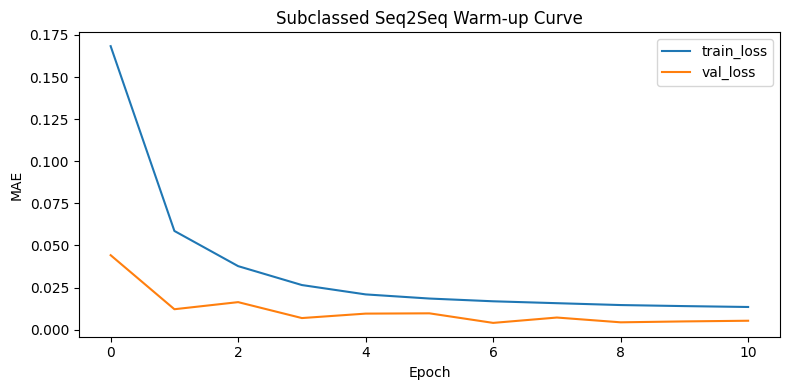

In [109]:
def make_seq2seq_tuple_dataset(encoder_inputs, decoder_inputs, targets, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(((encoder_inputs.astype(np.float32), decoder_inputs.astype(np.float32)), targets.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(encoder_inputs), 4096), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return dataset

train_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_train, train_decoder_inputs, y_train, shuffle=True)
val_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_val, val_decoder_inputs, y_val, shuffle=False)
test_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_test, test_decoder_inputs, y_test, shuffle=False)

subclassed_seq2seq_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='mae',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

warmup_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=4, restore_best_weights=True, min_delta=1e-4)
]

history_subclassed_seq2seq = subclassed_seq2seq_model.fit(
    train_seq2seq_tuple_ds,
    validation_data=val_seq2seq_tuple_ds,
    epochs=12,
    callbacks=warmup_callbacks,
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(history_subclassed_seq2seq.history['loss'], label='train_loss')
plt.plot(history_subclassed_seq2seq.history['val_loss'], label='val_loss')
plt.title('Subclassed Seq2Seq Warm-up Curve')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()


### Tambahan custom layer

In [110]:
def custom_mae(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs(y_true - y_pred))


def weighted_horizon_mae(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    horizon = tf.shape(y_true)[1]
    weights = tf.linspace(1.0, 1.15, horizon)
    weights = tf.reshape(weights, (1, horizon, 1))
    abs_error = tf.abs(y_true - y_pred)
    weighted_error = abs_error * weights
    return 0.92 * tf.reduce_mean(abs_error) + 0.08 * tf.reduce_mean(weighted_error)


def get_optimizer_lr(optimizer):
    learning_rate = optimizer.learning_rate
    if isinstance(learning_rate, tf.keras.optimizers.schedules.LearningRateSchedule):
        current_lr = learning_rate(optimizer.iterations)
        return float(tf.keras.backend.get_value(current_lr))
    if hasattr(learning_rate, 'numpy'):
        return float(learning_rate.numpy())
    return float(learning_rate)


def set_optimizer_lr(optimizer, new_lr):
    learning_rate = optimizer.learning_rate
    if hasattr(learning_rate, 'assign'):
        learning_rate.assign(new_lr)
    else:
        optimizer.learning_rate = new_lr


@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomEarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best = np.inf
        self.wait = 0
        self.best_weights = None
        self.stop_training = False

    def on_train_begin(self, model):
        self.best = np.inf
        self.wait = 0
        self.best_weights = model.get_weights() if self.restore_best_weights else None
        self.stop_training = False

    def on_epoch_end(self, model, optimizer, current, epoch):
        if current < (self.best - self.min_delta):
            self.best = current
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = model.get_weights()
            return False

        self.wait += 1
        if self.wait >= self.patience:
            self.stop_training = True
            if self.restore_best_weights and self.best_weights is not None:
                model.set_weights(self.best_weights)
            print(f'CustomEarlyStopping triggered at epoch {epoch:03d}. Best monitored metric: {self.best:.6f}')
            return True
        return False

    def get_config(self):
        return {
            'patience': self.patience,
            'min_delta': self.min_delta,
            'restore_best_weights': self.restore_best_weights,
        }


@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomReduceLROnPlateau:
    def __init__(self, factor=0.7, patience=2, min_lr=1e-5, min_delta=1e-4):
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.best = np.inf
        self.wait = 0

    def on_train_begin(self, model):
        self.best = np.inf
        self.wait = 0

    def on_epoch_end(self, model, optimizer, current, epoch):
        if current < (self.best - self.min_delta):
            self.best = current
            self.wait = 0
            return False

        self.wait += 1
        if self.wait >= self.patience:
            current_lr = get_optimizer_lr(optimizer)
            new_lr = max(current_lr * self.factor, self.min_lr)
            if new_lr < current_lr:
                set_optimizer_lr(optimizer, new_lr)
                print(f'CustomReduceLROnPlateau reduced lr from {current_lr:.6f} to {new_lr:.6f}')
            self.wait = 0
        return False

    def get_config(self):
        return {
            'factor': self.factor,
            'patience': self.patience,
            'min_lr': self.min_lr,
            'min_delta': self.min_delta,
        }


def call_model(model, batch_inputs, training=False):
    if isinstance(batch_inputs, dict):
        if {'encoder_inputs', 'decoder_inputs'}.issubset(batch_inputs.keys()):
            return model([batch_inputs['encoder_inputs'], batch_inputs['decoder_inputs']], training=training)
        return model(batch_inputs, training=training)
    if isinstance(batch_inputs, (tuple, list)):
        return model(batch_inputs, training=training)
    return model(batch_inputs, training=training)


def run_custom_training_loop(model, train_dataset, val_dataset, optimizer, loss_fn, epochs, callbacks=None):
    callbacks = callbacks or []
    for callback in callbacks:
        if hasattr(callback, 'on_train_begin'):
            callback.on_train_begin(model)

    @tf.function(reduce_retracing=True)
    def train_step(batch_inputs, batch_targets):
        with tf.GradientTape() as tape:
            predictions = call_model(model, batch_inputs, training=True)
            loss = loss_fn(batch_targets, predictions)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        mae = custom_mae(batch_targets, predictions)
        return loss, mae

    @tf.function(reduce_retracing=True)
    def validation_step(batch_inputs, batch_targets):
        predictions = call_model(model, batch_inputs, training=False)
        loss = loss_fn(batch_targets, predictions)
        mae = custom_mae(batch_targets, predictions)
        return loss, mae

    history_rows = []
    best_val_mae = np.inf
    best_weights = model.get_weights()

    for epoch in range(1, epochs + 1):
        train_loss_metric = tf.keras.metrics.Mean()
        train_mae_metric = tf.keras.metrics.Mean()
        val_loss_metric = tf.keras.metrics.Mean()
        val_mae_metric = tf.keras.metrics.Mean()

        for batch_inputs, batch_targets in train_dataset:
            batch_loss, batch_mae = train_step(batch_inputs, batch_targets)
            train_loss_metric.update_state(batch_loss)
            train_mae_metric.update_state(batch_mae)

        for batch_inputs, batch_targets in val_dataset:
            val_loss, val_mae = validation_step(batch_inputs, batch_targets)
            val_loss_metric.update_state(val_loss)
            val_mae_metric.update_state(val_mae)

        train_loss = float(train_loss_metric.result().numpy())
        train_mae = float(train_mae_metric.result().numpy())
        validation_loss = float(val_loss_metric.result().numpy())
        validation_mae = float(val_mae_metric.result().numpy())
        current_lr = get_optimizer_lr(optimizer)

        if validation_mae < best_val_mae:
            best_val_mae = validation_mae
            best_weights = model.get_weights()

        history_rows.append({
            'epoch': epoch,
            'loss': train_loss,
            'mae': train_mae,
            'val_loss': validation_loss,
            'val_mae': validation_mae,
            'lr': current_lr,
        })
        print(
            f'Epoch {epoch:03d}/{epochs:03d} - '
            f'loss: {train_loss:.6f} - mae: {train_mae:.6f} - '
            f'val_loss: {validation_loss:.6f} - val_mae: {validation_mae:.6f} - '
            f'lr: {current_lr:.6f}'
        )

        should_stop = False
        for callback in callbacks:
            if hasattr(callback, 'on_epoch_end'):
                should_stop = callback.on_epoch_end(model, optimizer, validation_mae, epoch) or should_stop
        if should_stop:
            break

    model.set_weights(best_weights)
    history_df = pd.DataFrame(history_rows)
    display(history_df)
    print(f'Best validation MAE restored: {best_val_mae:.6f}')
    return history_df


### Fungsi evaluasi

In [111]:
def predict_baseline_direct(model, X_test_array, batch_size=BATCH_SIZE):
    predictions = model.predict(X_test_array, batch_size=batch_size, verbose=0)
    return np.asarray(predictions, dtype=np.float32)


def predict_seq2seq_autoregressive(model, X_test_array, last_close_values, horizon=HORIZON, batch_size=BATCH_SIZE):
    all_predictions = []

    for start in range(0, len(X_test_array), batch_size):
        x_batch = tf.convert_to_tensor(X_test_array[start:start + batch_size], dtype=tf.float32)
        last_close_batch = tf.convert_to_tensor(last_close_values[start:start + batch_size], dtype=tf.float32)

        encoder_outputs, state_h, state_c = model.encode(x_batch, training=False)
        states = [state_h, state_c]
        decoder_input = tf.reshape(last_close_batch, (-1, 1, 1))

        step_predictions = []
        for _ in range(horizon):
            next_step, states = model.decode_step(decoder_input, encoder_outputs, states, training=False)
            step_predictions.append(next_step)
            decoder_input = next_step

        batch_predictions = tf.concat(step_predictions, axis=1)
        all_predictions.append(batch_predictions.numpy())

    return np.concatenate(all_predictions, axis=0).astype(np.float32)


def evaluate_test_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.mean(np.abs(y_true - y_pred)))


def inverse_close_sequences(close_scaler, sequences_scaled):
    sequences_scaled = np.asarray(sequences_scaled, dtype=np.float32)
    flat_values = sequences_scaled.reshape(-1, 1)
    inverted = close_scaler.inverse_transform(flat_values)
    return inverted.reshape(sequences_scaled.shape)


def evaluate_mae_table(model_name, y_true_scaled, y_pred_scaled, close_scaler=None, horizon=HORIZON):
    if close_scaler is None:
        close_scaler = scalers[TARGET]

    mae_scaled = evaluate_test_mae(y_true_scaled, y_pred_scaled)

    actual_unscaled = inverse_close_sequences(close_scaler, y_true_scaled)
    predicted_unscaled = inverse_close_sequences(close_scaler, y_pred_scaled)

    comparison_df = pd.DataFrame({
        'jam_ke': np.arange(1, horizon + 1),
        'data_aktual': actual_unscaled[0, :, 0],
        'hasil_prediksi': predicted_unscaled[0, :, 0],
    })
    comparison_df['selisih'] = comparison_df['hasil_prediksi'] - comparison_df['data_aktual']

    print(f'{model_name} test MAE (scaled): {mae_scaled:.6f}')
    display(comparison_df)
    return mae_scaled, comparison_df


## Training

In [112]:
baseline_LSTM_model = build_attention_baseline_model(
    WINDOW_SIZE,
    len(FEATURE),
    HORIZON,
    lstm_units=MODEL_UNITS,
    num_heads=NUM_HEADS,
    key_dim=KEY_DIM,
    dropout=DROPOUT_RATE,
)

seq2seq_LSTM_model = SubclassedSeq2Seq(
    horizon=HORIZON,
    lstm_units=MODEL_UNITS,
    num_heads=NUM_HEADS,
    key_dim=KEY_DIM,
    dropout=DROPOUT_RATE,
    name='subclassed_seq2seq_LSTM_model',
)

_ = baseline_LSTM_model(tf.convert_to_tensor(X_train[:1], dtype=tf.float32), training=False)
_ = seq2seq_LSTM_model(
    [
        tf.convert_to_tensor(X_train[:1], dtype=tf.float32),
        tf.convert_to_tensor(train_decoder_inputs[:1], dtype=tf.float32),
    ],
    training=False,
)

seq2seq_LSTM_model.set_weights(subclassed_seq2seq_model.get_weights())

baseline_optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
seq2seq_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, clipnorm=1.0)

baseline_callbacks = [
    CustomEarlyStopping(patience=4, min_delta=1e-4, restore_best_weights=True),
    CustomReduceLROnPlateau(factor=0.7, patience=2, min_lr=1e-5, min_delta=1e-4),
]

seq2seq_callbacks = [
    CustomEarlyStopping(patience=15, min_delta=1e-4, restore_best_weights=True),
    CustomReduceLROnPlateau(factor=0.7, patience=2, min_lr=1e-5, min_delta=1e-4),
]


In [113]:
print('Training custom lstm baseline model')
baseline_history_custom_df = run_custom_training_loop(
    baseline_LSTM_model,
    train_ds,
    val_ds,
    optimizer=baseline_optimizer,
    loss_fn=weighted_horizon_mae,
    epochs=CUSTOM_BASELINE_EPOCHS,
    callbacks=baseline_callbacks,
)

Training custom lstm baseline model
Epoch 001/006 - loss: 0.066415 - mae: 0.066014 - val_loss: 0.019895 - val_mae: 0.019780 - lr: 0.000300
Epoch 002/006 - loss: 0.019095 - mae: 0.018972 - val_loss: 0.013191 - val_mae: 0.013117 - lr: 0.000300
Epoch 003/006 - loss: 0.017174 - mae: 0.017062 - val_loss: 0.012587 - val_mae: 0.012515 - lr: 0.000300
Epoch 004/006 - loss: 0.016372 - mae: 0.016264 - val_loss: 0.011099 - val_mae: 0.011035 - lr: 0.000300
Epoch 005/006 - loss: 0.015641 - mae: 0.015536 - val_loss: 0.010082 - val_mae: 0.010023 - lr: 0.000300
Epoch 006/006 - loss: 0.015302 - mae: 0.015200 - val_loss: 0.009833 - val_mae: 0.009776 - lr: 0.000300


,epoch,loss,mae,val_loss,val_mae,lr
0,1,0.066415,0.066014,0.019895,0.019780,0.0003
1,2,0.019095,0.018972,0.013191,0.013117,0.0003
2,3,0.017174,0.017062,0.012587,0.012515,0.0003
3,4,0.016372,0.016264,0.011099,0.011035,0.0003
4,5,0.015641,0.015536,0.010082,0.010023,0.0003
5,6,0.015302,0.015200,0.009833,0.009776,0.0003


Best validation MAE restored: 0.009776


In [114]:
print('Training custom seq2seq model')
seq2seq_history_custom_df = run_custom_training_loop(
    seq2seq_LSTM_model,
    train_seq2seq_tuple_ds,
    val_seq2seq_tuple_ds,
    optimizer=seq2seq_optimizer,
    loss_fn=weighted_horizon_mae,
    epochs=CUSTOM_SEQ2SEQ_EPOCHS,
    callbacks=seq2seq_callbacks,
)

Training custom seq2seq model
Epoch 001/020 - loss: 0.016267 - mae: 0.016174 - val_loss: 0.004234 - val_mae: 0.004209 - lr: 0.000200
Epoch 002/020 - loss: 0.014464 - mae: 0.014381 - val_loss: 0.003420 - val_mae: 0.003401 - lr: 0.000200
Epoch 003/020 - loss: 0.013879 - mae: 0.013798 - val_loss: 0.004317 - val_mae: 0.004291 - lr: 0.000200
Epoch 004/020 - loss: 0.013008 - mae: 0.012933 - val_loss: 0.003391 - val_mae: 0.003373 - lr: 0.000200
CustomReduceLROnPlateau reduced lr from 0.000200 to 0.000140
Epoch 005/020 - loss: 0.012566 - mae: 0.012493 - val_loss: 0.004434 - val_mae: 0.004408 - lr: 0.000140
Epoch 006/020 - loss: 0.012126 - mae: 0.012055 - val_loss: 0.002926 - val_mae: 0.002909 - lr: 0.000140
Epoch 007/020 - loss: 0.011833 - mae: 0.011764 - val_loss: 0.002982 - val_mae: 0.002965 - lr: 0.000140
Epoch 008/020 - loss: 0.011517 - mae: 0.011450 - val_loss: 0.003240 - val_mae: 0.003224 - lr: 0.000140
CustomReduceLROnPlateau reduced lr from 0.000140 to 0.000098
Epoch 009/020 - loss: 0.

,epoch,loss,mae,val_loss,val_mae,lr
0,1,0.016267,0.016174,0.004234,0.004209,0.000200
1,2,0.014464,0.014381,0.003420,0.003401,0.000200
2,3,0.013879,0.013798,0.004317,0.004291,0.000200
3,4,0.013008,0.012933,0.003391,0.003373,0.000200
4,5,0.012566,0.012493,0.004434,0.004408,0.000140
5,6,0.012126,0.012055,0.002926,0.002909,0.000140
6,7,0.011833,0.011764,0.002982,0.002965,0.000140
7,8,0.011517,0.011450,0.003240,0.003224,0.000140
8,9,0.011216,0.011151,0.004797,0.004770,0.000098
9,10,0.011118,0.011053,0.004556,0.004530,0.000098


Best validation MAE restored: 0.002343


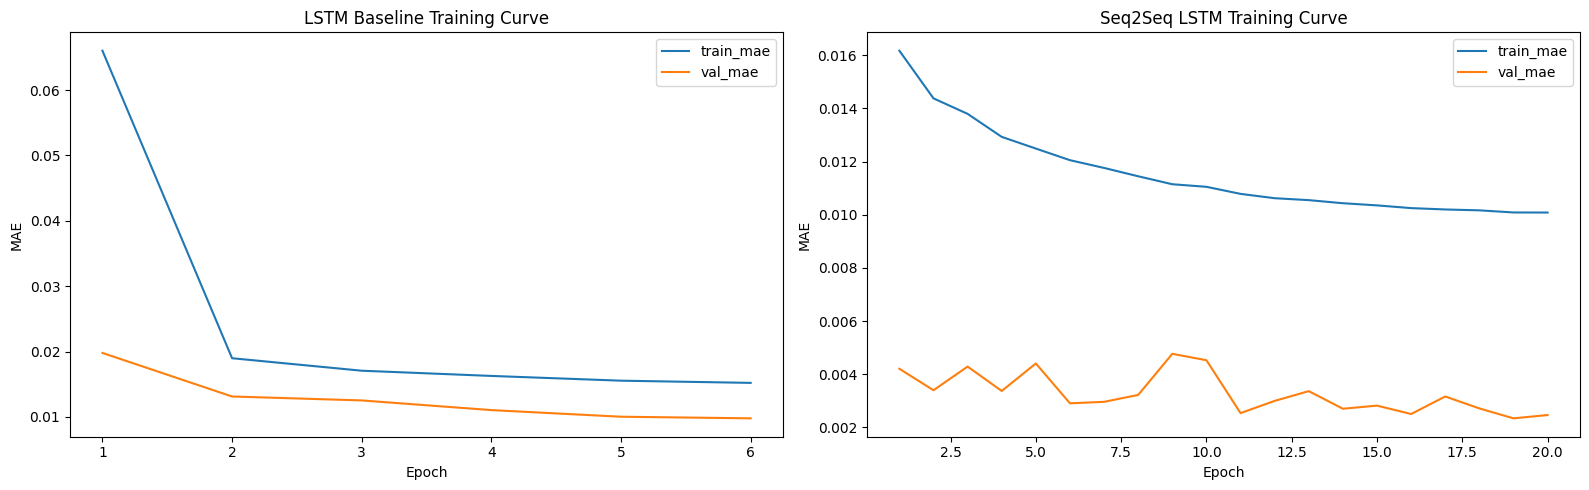

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(baseline_history_custom_df['epoch'], baseline_history_custom_df['mae'], label='train_mae')
axes[0].plot(baseline_history_custom_df['epoch'], baseline_history_custom_df['val_mae'], label='val_mae')
axes[0].set_title('LSTM Baseline Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(seq2seq_history_custom_df['epoch'], seq2seq_history_custom_df['mae'], label='train_mae')
axes[1].plot(seq2seq_history_custom_df['epoch'], seq2seq_history_custom_df['val_mae'], label='val_mae')
axes[1].set_title('Seq2Seq LSTM Training Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
plt.tight_layout()
plt.show()

In [116]:
baseline_test_predictions = predict_baseline_direct(
    baseline_LSTM_model, 
    X_test
)

seq2seq_test_predictions = predict_seq2seq_autoregressive(
    seq2seq_LSTM_model,
    X_test,
    test_last_close,
    horizon=HORIZON,
    batch_size=BATCH_SIZE,
)

baseline_custom_mae, baseline_custom_comparison_df = evaluate_mae_table(
    'Baseline LSTM Model with Attention',
    y_test,
    baseline_test_predictions,
)

seq2seq_custom_mae, seq2seq_custom_comparison_df = evaluate_mae_table(
    'Seq2Seq LSTM Model (Autoregressive)',
    y_test,
    seq2seq_test_predictions,
)

Baseline LSTM Model with Attention test MAE (scaled): 0.014248


,jam_ke,data_aktual,hasil_prediksi,selisih
0,1,3568.480225,3584.584229,16.104004
1,2,3549.670166,3649.449707,99.779541
2,3,3557.280029,3726.803223,169.523193
3,4,3544.530029,3674.179932,129.649902
4,5,3541.969971,3684.968018,142.998047
5,6,3548.699951,3736.067871,187.367920
6,7,3553.140137,3417.393555,-135.746582
7,8,3563.010010,3602.310059,39.300049
8,9,3566.919922,3781.411133,214.491211
9,10,3557.729980,3532.948730,-24.781250


Seq2Seq LSTM Model (Autoregressive) test MAE (scaled): 0.019642


,jam_ke,data_aktual,hasil_prediksi,selisih
0,1,3568.480225,3574.270264,5.790039
1,2,3549.670166,3528.222412,-21.447754
2,3,3557.280029,3498.882080,-58.397949
3,4,3544.530029,3478.391602,-66.138428
4,5,3541.969971,3463.451416,-78.518555
5,6,3548.699951,3449.583496,-99.116455
6,7,3553.140137,3435.790283,-117.349854
7,8,3563.010010,3421.588623,-141.421387
8,9,3566.919922,3406.825439,-160.094482
9,10,3557.729980,3391.555420,-166.174561


# Comparison MAE Baseline LSTM vs Seq2Seq LSTM

In [117]:
comparison_summary_df = pd.DataFrame({
    'model': ['baseline_LSTM_model', 'seq2seq_LSTM_model'],
    'test_mae_scaled': [baseline_custom_mae, seq2seq_custom_mae],
})
display(comparison_summary_df.sort_values('test_mae_scaled'))

,model,test_mae_scaled
0,baseline_LSTM_model,0.014248
1,seq2seq_LSTM_model,0.019642


In [118]:
baseline_LSTM_model.save('model_baseline_LSTM.keras')
seq2seq_LSTM_model.save('model_seq2seq_LSTM.keras')

## Line chart baseline LSTM

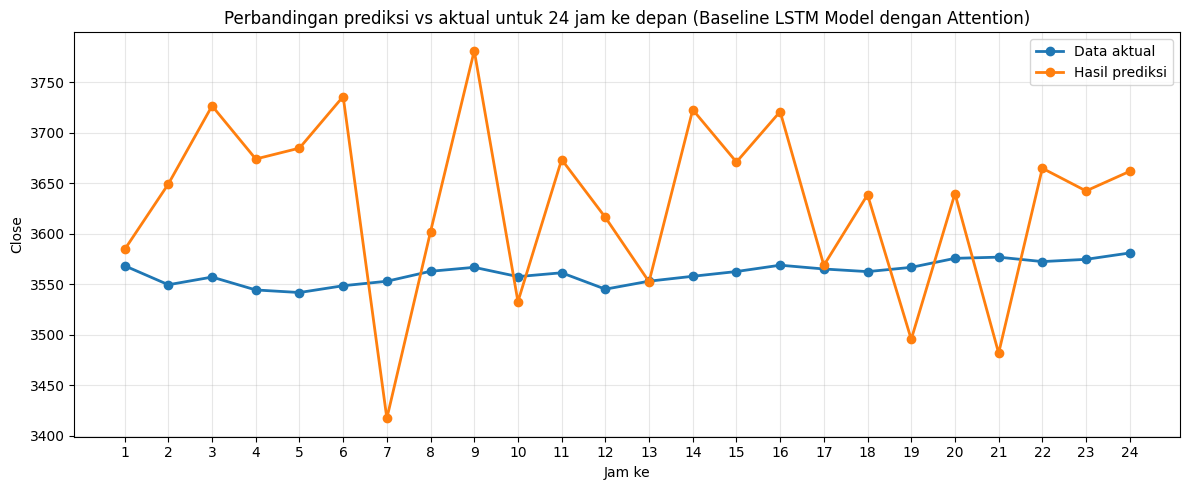

In [119]:
plt.figure(figsize=(12, 5))
plt.plot(
    baseline_custom_comparison_df['jam_ke'],
    baseline_custom_comparison_df['data_aktual'],
    marker='o',
    linewidth=2,
    label='Data aktual',
)
plt.plot(
    baseline_custom_comparison_df['jam_ke'],
    baseline_custom_comparison_df['hasil_prediksi'],
    marker='o',
    linewidth=2,
    label='Hasil prediksi',
)
plt.title('Perbandingan prediksi vs aktual untuk 24 jam ke depan (Baseline LSTM Model dengan Attention)')
plt.xlabel('Jam ke')
plt.ylabel('Close')
plt.xticks(baseline_custom_comparison_df['jam_ke'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Line chart Seq2Seq LSTM

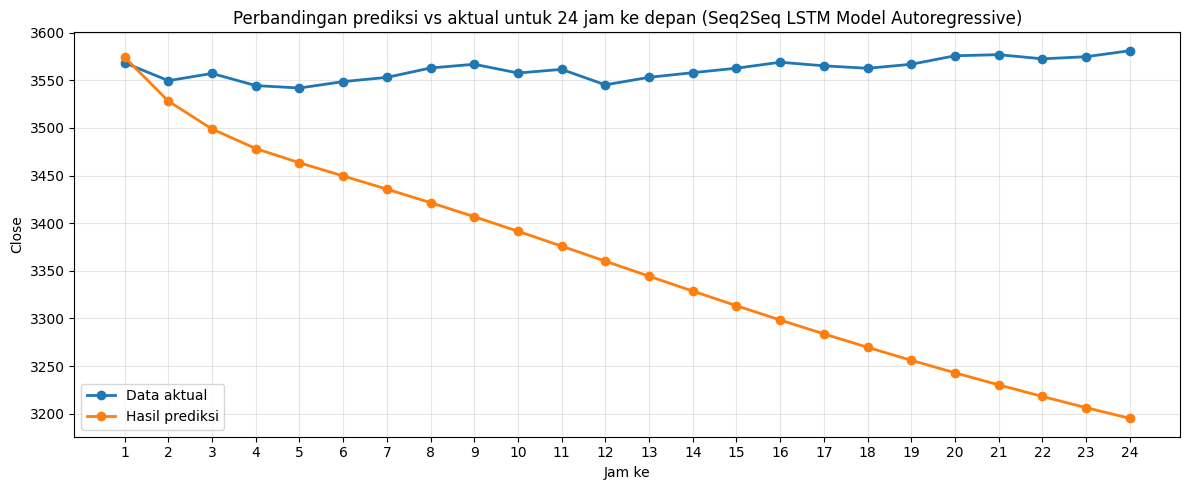

In [120]:
plt.figure(figsize=(12, 5))
plt.plot(
    seq2seq_custom_comparison_df['jam_ke'],
    seq2seq_custom_comparison_df['data_aktual'],
    marker='o',
    linewidth=2,
    label='Data aktual',
)
plt.plot(
    seq2seq_custom_comparison_df['jam_ke'],
    seq2seq_custom_comparison_df['hasil_prediksi'],
    marker='o',
    linewidth=2,
    label='Hasil prediksi',
)
plt.title('Perbandingan prediksi vs aktual untuk 24 jam ke depan (Seq2Seq LSTM Model Autoregressive)')
plt.xlabel('Jam ke')
plt.ylabel('Close')
plt.xticks(seq2seq_custom_comparison_df['jam_ke'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [121]:
seq2seq_LSTM_model.save('best_model_seq2seq_LSTM.keras')